<a href="https://colab.research.google.com/github/bihterk/006_ConfigXMLSpEL/blob/master/Topic_Modeling_week_3_Agentic_ish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3

You will work on the PureGym dataset trying to obtain actionable insights from two separate review datasets.



There are several ways to solve lots of different problems, but in this instance, you will be working with Google Reviews and TrustPilot Reviews.

In order to solve any problem you should:


*   Consider similar problems and how they have been solved
*   Think about techniques that are relevant to solving this kind of problem
*   Be clear about what the problem statement is asking
*   What data is relevant to the required answer



When it comes to this kind of problem you will have a number of reviews from a number of customers.

The most important parts of this could be:

1. Review text
2. Score (i.e. 1-5 stars)
3. Datetime (i.e. day and time) of review
4. Location

In this lecture, we are going to make some synthesized datasets for Google and TrustPilot reviews. Our synthesised datasets will be based upon a fake popular fastfood chain in the UK known as Russell's Famous Food.

# Imports

In [ ]:
!pip install -U plotly==5.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 71.5 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk import sent_tokenize, word_tokenize
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
from nltk.tokenize import RegexpTokenizer

import seaborn as sns
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Let's start by considering the review text itself.

If you have two different datasets it is sometimes important to understand that even if you assume that they should be the same i.e. review data, it does not mean that they are.

People may use your product in different ways and engage in reviewing your product in different ways.

So, initially, let's do something quite basic and create a word cloud. Making a visualisation like this is something we can do quickly in order to potentially get a quick win.

Imagine if you spent days getting to the bottom of a problem when quick solutions that could be actioned were available within minutes. It doesn't mean all problems are solved, but it could point you in the right direction and clarify some low hanging fruit.

# Helper function

Here we will create a function that will show a WordCloud and a Frequency plot of the most used words.

In [ ]:
def word_cloud_display(df, key):
  top_number_of_results = 100
  all_reviews = df[key].str.lower().str.cat(sep=' ')
  all_text = re.sub('[^A-Za-z]+', ' ', all_reviews)

  stop_words = set(stopwords.words('english'))
  word_tokens = word_tokenize(all_text)
  filtered_all_reviews = [w for w in word_tokens if not w in stop_words]
  filtered_all_reviews = []
  for w in word_tokens:
      if w not in stop_words:
          filtered_all_reviews.append(w)

  all_reviews_no_short_words = [word for word in filtered_all_reviews if len(word) > 2]
  all_reviews_no_numbers = [word for word in all_reviews_no_short_words if not word.isnumeric()]
  word_distribution = nltk.FreqDist(all_reviews_no_numbers)
  reviews_word_frequency_distribution_df = pd.DataFrame(word_distribution.most_common(top_number_of_results),
                    columns=['Word', 'Frequency'])

  plt.figure(figsize=(10,10))
  sns.set_style("whitegrid")
  ax = sns.barplot(x="Word",y="Frequency", data=reviews_word_frequency_distribution_df.head(7))

  plt.figure(figsize = (100,100))
  wc = WordCloud(background_color = 'black', max_words = 1000,  max_font_size = 50)
  wc.generate(' '.join(all_reviews_no_numbers))
  plt.imshow(wc)
  plt.axis('off')

# Initial Review

We have two synthetic datasets for Russells Famous Food restaurants. One for TrustPilot and the other for Google.

This can be related to the datasets you will use for the PureGym problem.

In [ ]:
rff_trustpilot_df = pd.read_csv('Russells_Famous_Food_TP.csv')
rff_google_df = pd.read_csv('Russells_Famous_Food_Google.csv')

Now, let's take a sneak peak at our TrustPilot data.

In [ ]:
rff_trustpilot_df.head()

,Review Text,Review Stars,Location,DateTime
0,Delicious meals and very clean environment.,4,London Chelsea,2023-07-31 02:24:00.048415
1,Terrible service and cold food.,1,Manchester Salford,2023-07-31 02:24:00.048415
2,"Amazing experience, highly recommend.",4,London Canary Wharf,2023-07-31 02:24:00.048415
3,"It was alright, the service could be better.",3,Leeds City Centre,2023-07-31 02:24:00.048415
4,"Awful place, would not recommend.",1,London Canary Wharf,2023-07-31 02:24:00.048415


As you can see, we have a simplified dataframe with 4 columns:

* **Review Text** - has the review written by the customers
* **Review Stars** - has the number of stars given our of 5 by the customer
* **Location** - has the locations of the restaurants
* **DateTime** - has the date and time of the review given

Now, lets have a peak at our Google reviews.

In [ ]:
rff_google_df.head()

,Review Text,Review Stars,Restaurant Place,Creationdate
0,Good meal but a bit overpriced.,3,Birmingham City Centre,2022-07-31 02:53:37.218490
1,"Average experience, nothing to write home about.",3,London Canary Wharf,2022-07-31 02:53:37.218490
2,"Decent food, but the service was lacking.",2,Edinburgh Old Town,2022-07-31 02:53:37.218490
3,"Food was okay, but the place was quite dirty.",2,Cardiff Bay,2022-07-31 02:53:37.218490
4,"Decent food, but the service was lacking.",4,Sheffield Ecclesall Road,2022-07-31 02:53:37.218490


As you can see, we have a simplified dataframe with 4 columns:

* **Review Text** - has the review written by the customers
* **Review Stars** - has the number of stars given our of 5 by the customer
* **Restaurant Place** - has the locations of the restaurants
* **Creationdate** - has the date and time of the review given

**Locations**

Firstly, let's review our locations. The reason for this is because we must consider spatial and temporal components of the data.

It may be the case that reviews have a similar pattern, for example, around a marketing campaign. Or in our case, with a "real, physical" entity, rather than a website, location is likely to play a role in reviews and correlated findings.

Here, we are extracting locations from the TrustPilot dataframe and turning them into a list.

In [ ]:
trustpilot_locations = rff_trustpilot_df['Location'].unique()
trustpilot_locations = trustpilot_locations.astype(str)
trustpilot_locations_sorted = np.sort(trustpilot_locations).tolist()
len(trustpilot_locations)

25

Similarly, with the Google reviews.

In [ ]:
google_locations = rff_google_df['Restaurant Place'].unique()
google_locations = google_locations.astype(str)
google_locations_sorted = np.sort(google_locations)
len(google_locations)

25

Now, we just do a simple check and see if there is any overlap and thankfully in this case all locations will overlap.

You should note that this will **NOT** be likely with the PureGym or an real-world problem.

In [ ]:
intersection_of_locations = [ e for e in trustpilot_locations if e in google_locations ]
len(intersection_of_locations)

25

Perfect, they overlap almost exactly!! Again, the benefits of synthetic data for demonstration purposes.

**Time**

Now that we have looked at locations, we should probably see if the reviews sync up.

To do this, we must convert the data to some kind of time-series. So, where we have the date and time, we can remove the time part and group by date, counting the number of reviews on that day.

Let's do it for TrustPilot first.

In [ ]:
rff_trustpilot_df_by_days = rff_trustpilot_df.copy()

In [ ]:
rff_trustpilot_df_by_days["DateTime"] = pd.to_datetime(rff_trustpilot_df_by_days["DateTime"], errors='coerce')

<Axes: xlabel='day'>

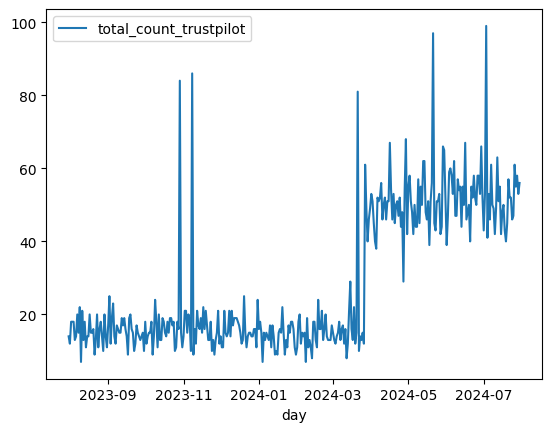

In [ ]:
rff_trustpilot_df_by_days["day"] = rff_trustpilot_df_by_days["DateTime"].dt.date
rff_trustpilot_df_by_days_with_review_count = rff_trustpilot_df_by_days.groupby(["day"])["day"].count().reset_index(name='total_count_trustpilot')
rff_trustpilot_df_by_days_with_review_count_sorted = rff_trustpilot_df_by_days_with_review_count.sort_values(by=['day'], ascending=True)
rff_trustpilot_df_by_days_with_review_count_sorted = rff_trustpilot_df_by_days_with_review_count_sorted.set_index("day")
rff_trustpilot_df_by_days_with_review_count_sorted.plot()

Now, for Google:

In [ ]:
rff_google_df_by_days = rff_google_df.copy()

In [ ]:
rff_google_df_by_days["Creationdate"] = pd.to_datetime(rff_google_df_by_days["Creationdate"], errors='coerce')

<Axes: xlabel='day'>

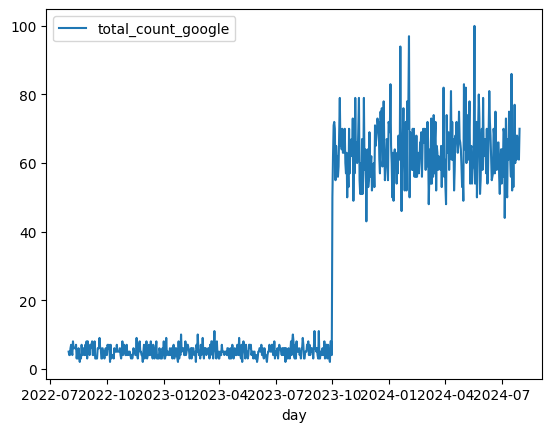

In [ ]:
rff_google_df_by_days["day"] = rff_google_df_by_days["Creationdate"].dt.date
rff_google_df_by_days_with_review_count = rff_google_df_by_days.groupby(["day"])["day"].count().reset_index(name='total_count_google')
rff_google_df_by_days_with_review_count_sorted = rff_google_df_by_days_with_review_count.sort_values(by=['day'], ascending=True)
rff_google_df_by_days_with_review_count_sorted = rff_google_df_by_days_with_review_count_sorted.set_index("day")
rff_google_df_by_days_with_review_count_sorted.plot()

We find that one review dataset is longer than the other (Google) and that before a particular point (perhaps when the restaurant started pushing for feedback ... we don't know) there very little reviews. There doesn't appear to be any other types of temporal correlations i.e. in Summer there are more negative reviews because of temperature, or something like that.

**Word Cloud**

Ok, great. Well, now we have looked over locations and time with not much to go on just now, let's take a look at a WordCloud. A great way to visualise qualitative data.

We will use our helper function and pass in our TrustPilot data and the column name **Review Text**.

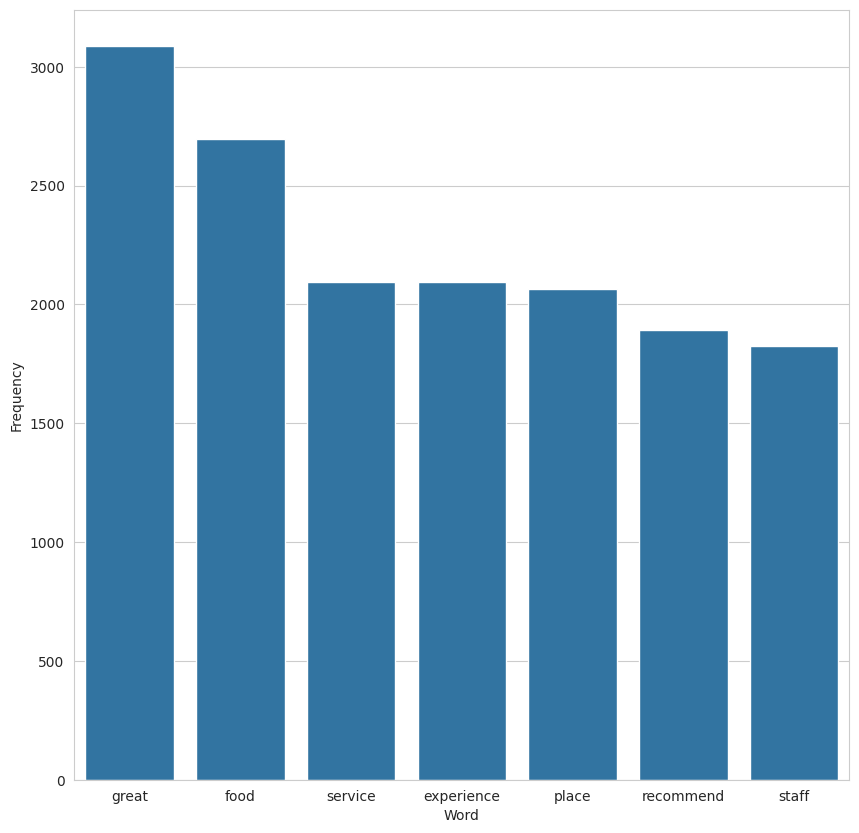

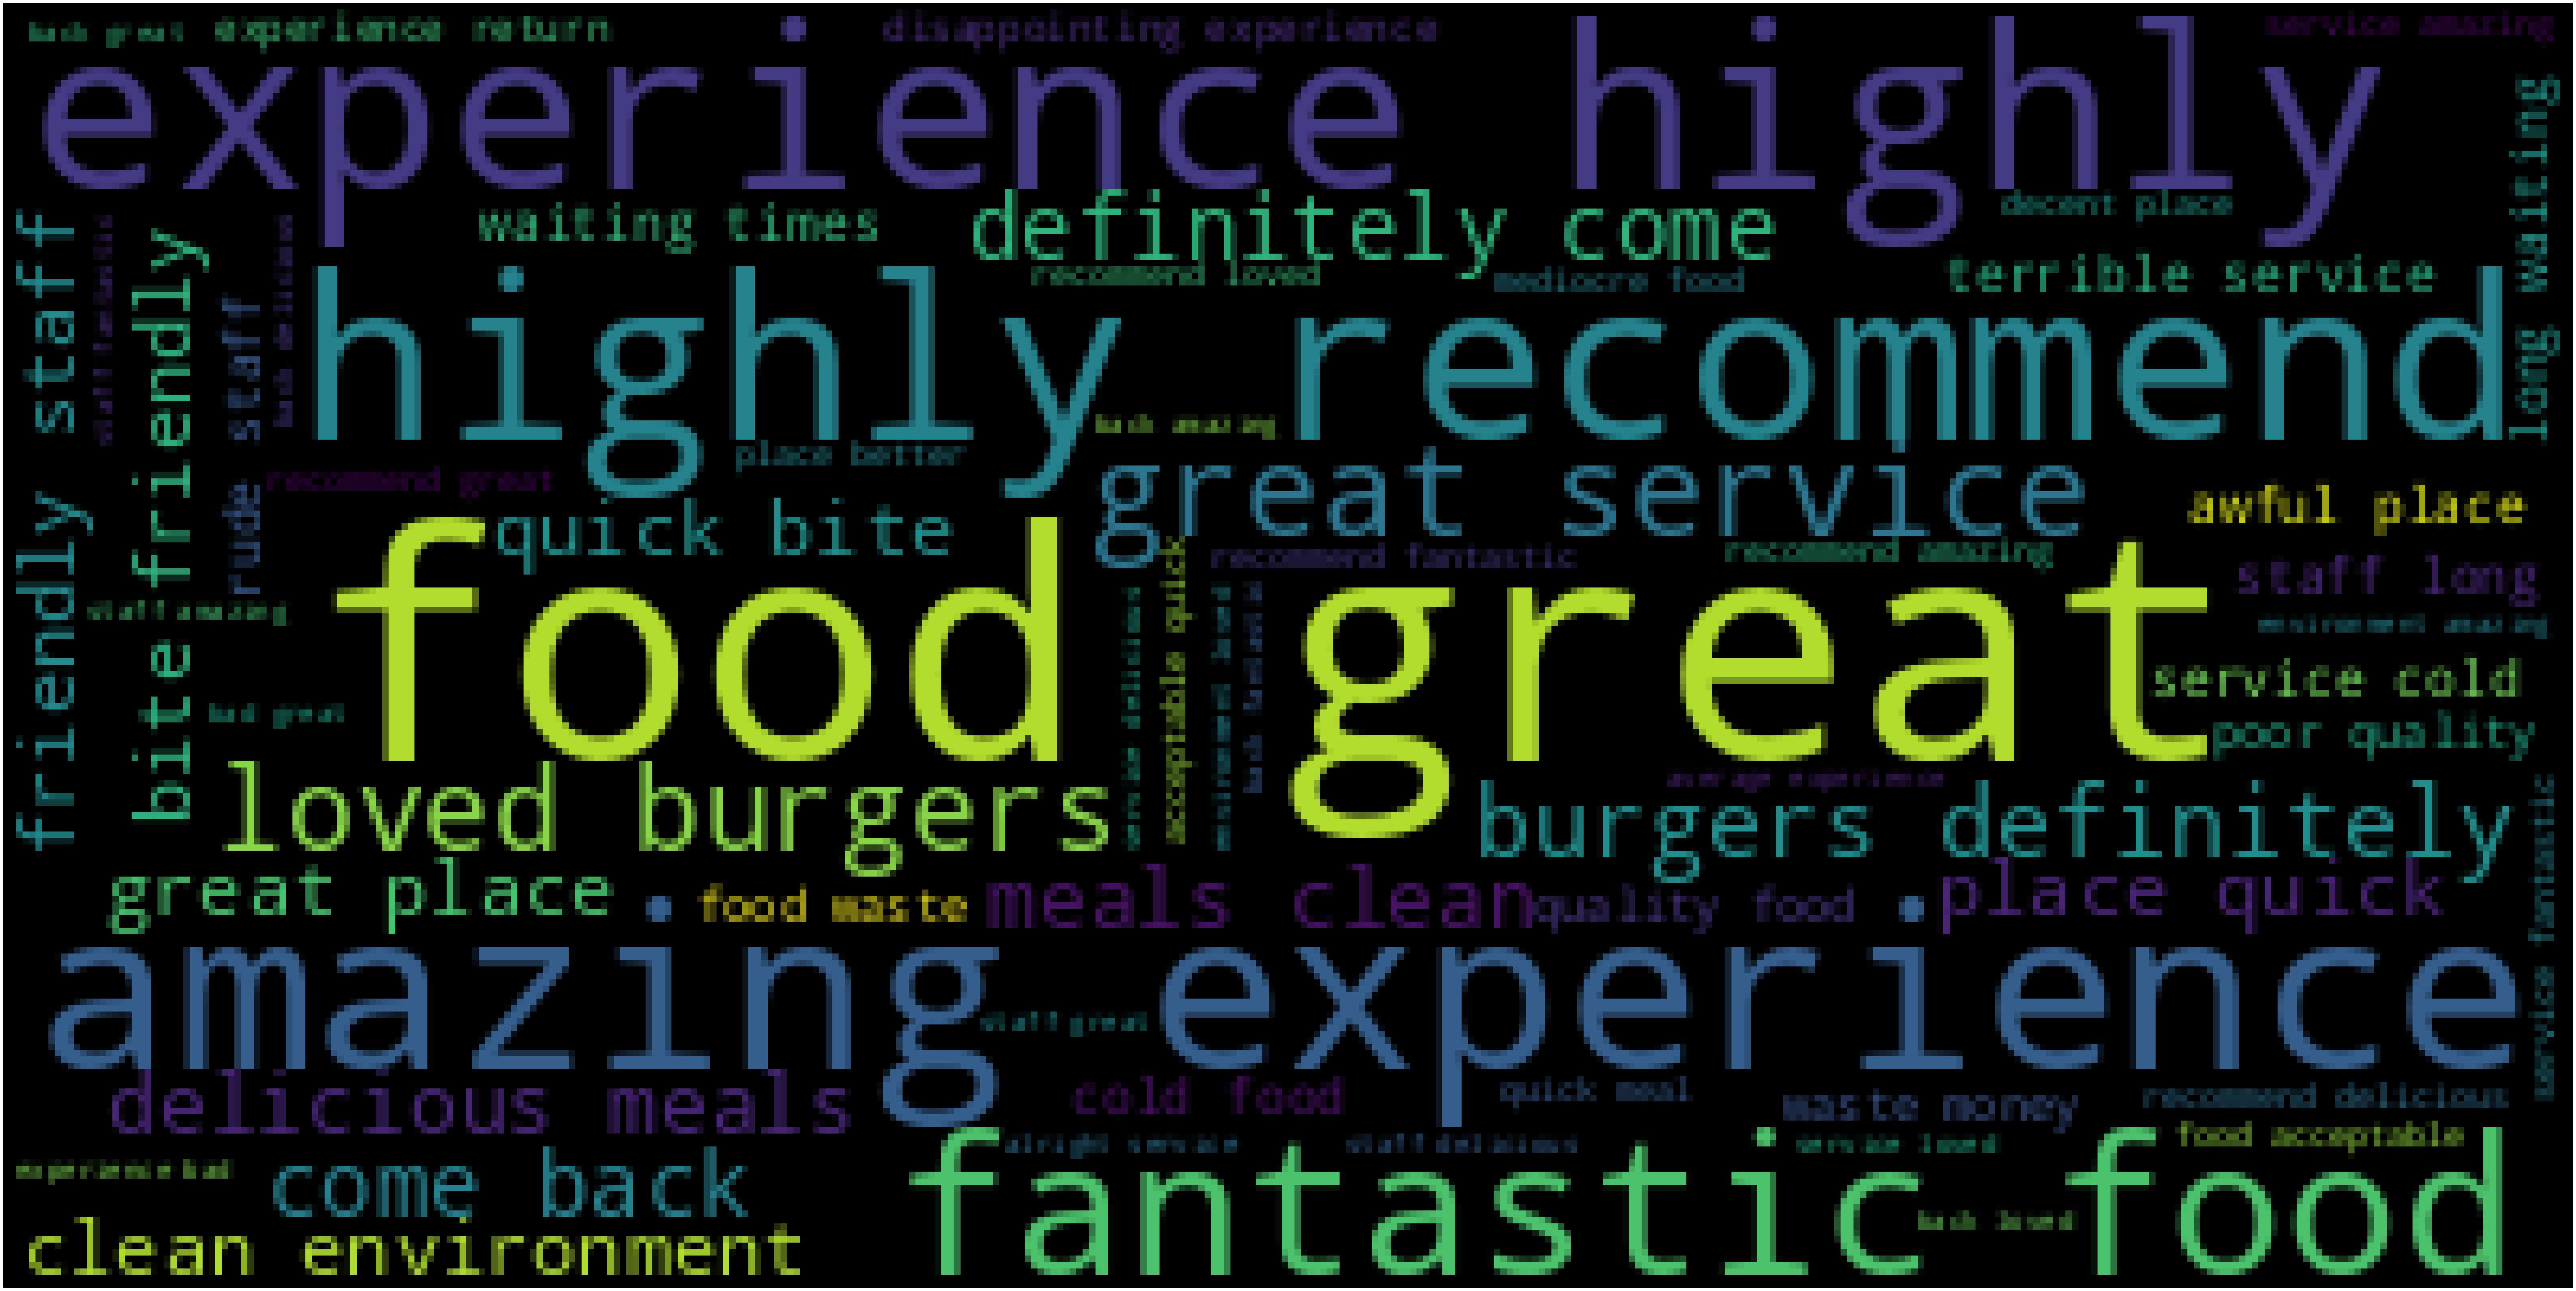

In [ ]:
word_cloud_display(rff_trustpilot_df_by_days, 'Review Text')

Initially, things are looking great. In fact, great is the most common word with food, experience, service and recommend all being in there too. We, as a company, seem to be doing really well.

This doesn't give us much to go on in terms of actionable insights, however.

Let's try Google in the same way.

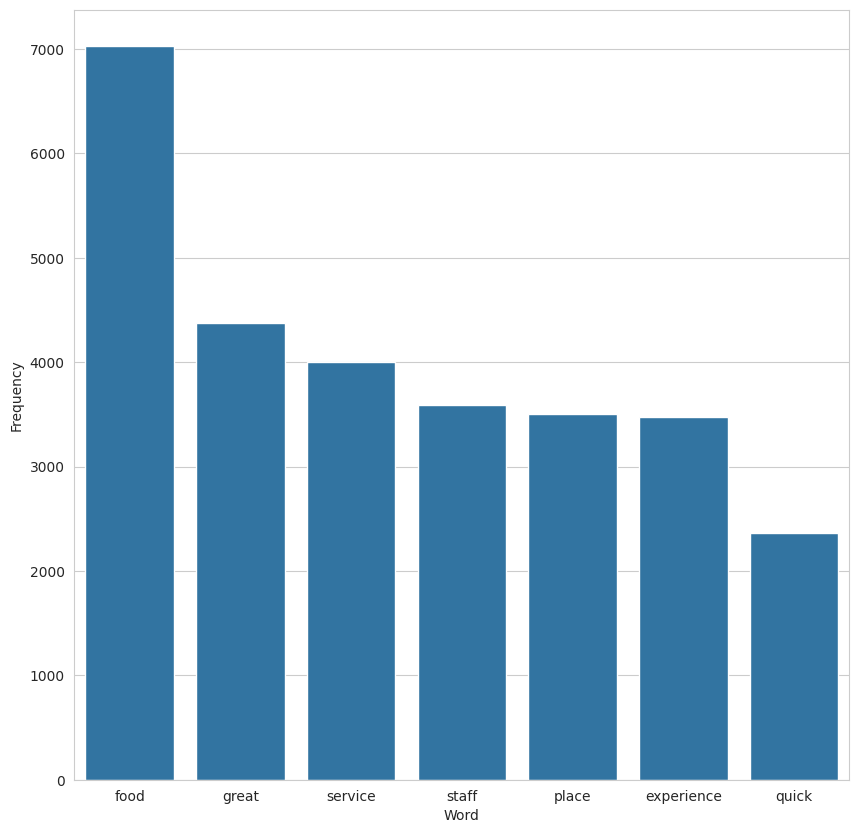

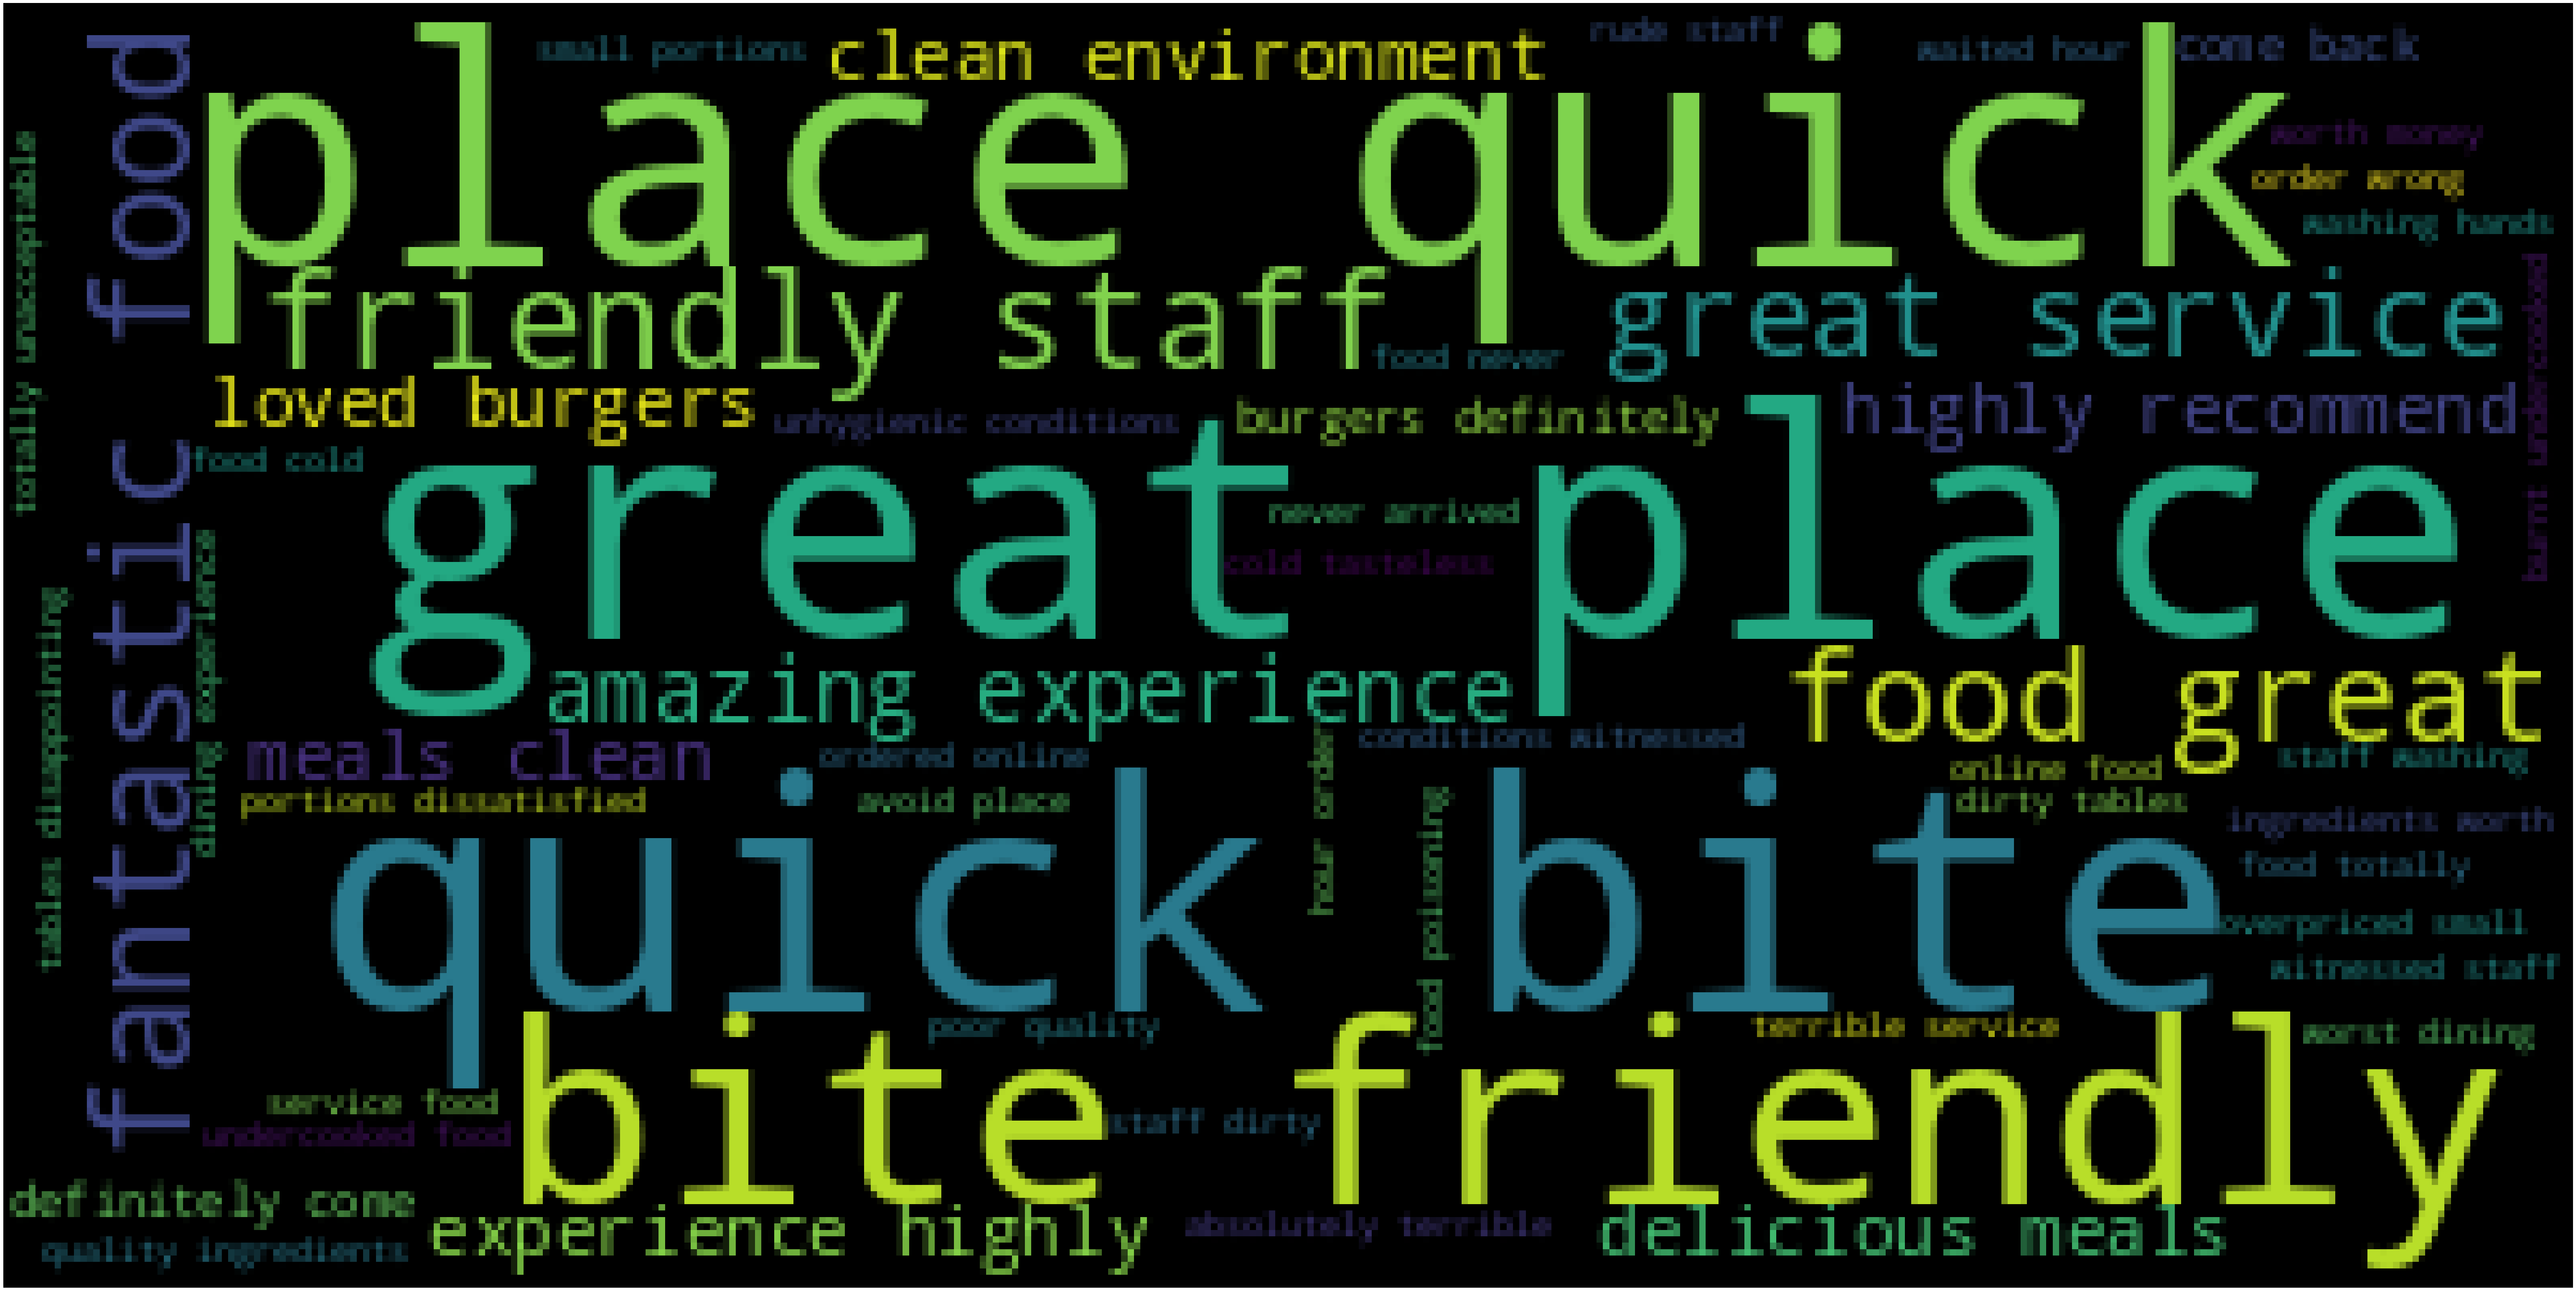

In [ ]:
word_cloud_display(rff_google_df_by_days, 'Review Text')

Looks like we are doing great overall!

In that case, let's split good reviews and bad reviews.

In [ ]:
rff_google_df.head()

,Review Text,Review Stars,Restaurant Place,Creationdate
0,Good meal but a bit overpriced.,3,Birmingham City Centre,2022-07-31 02:53:37.218490
1,"Average experience, nothing to write home about.",3,London Canary Wharf,2022-07-31 02:53:37.218490
2,"Decent food, but the service was lacking.",2,Edinburgh Old Town,2022-07-31 02:53:37.218490
3,"Food was okay, but the place was quite dirty.",2,Cardiff Bay,2022-07-31 02:53:37.218490
4,"Decent food, but the service was lacking.",4,Sheffield Ecclesall Road,2022-07-31 02:53:37.218490


We will define bad reviews as anything under 3 stars.

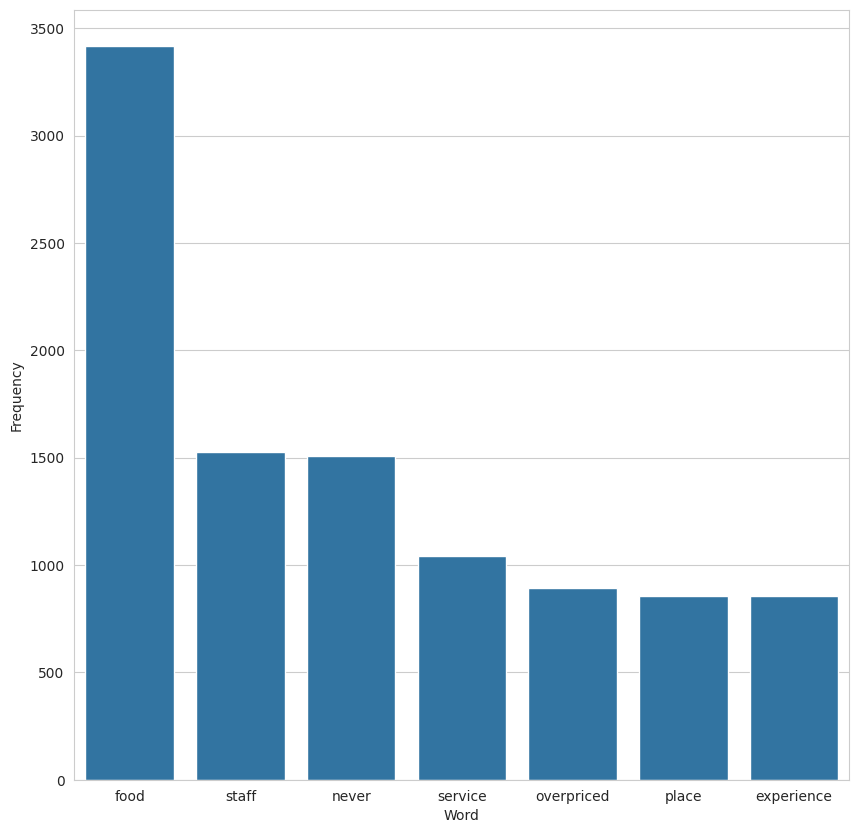

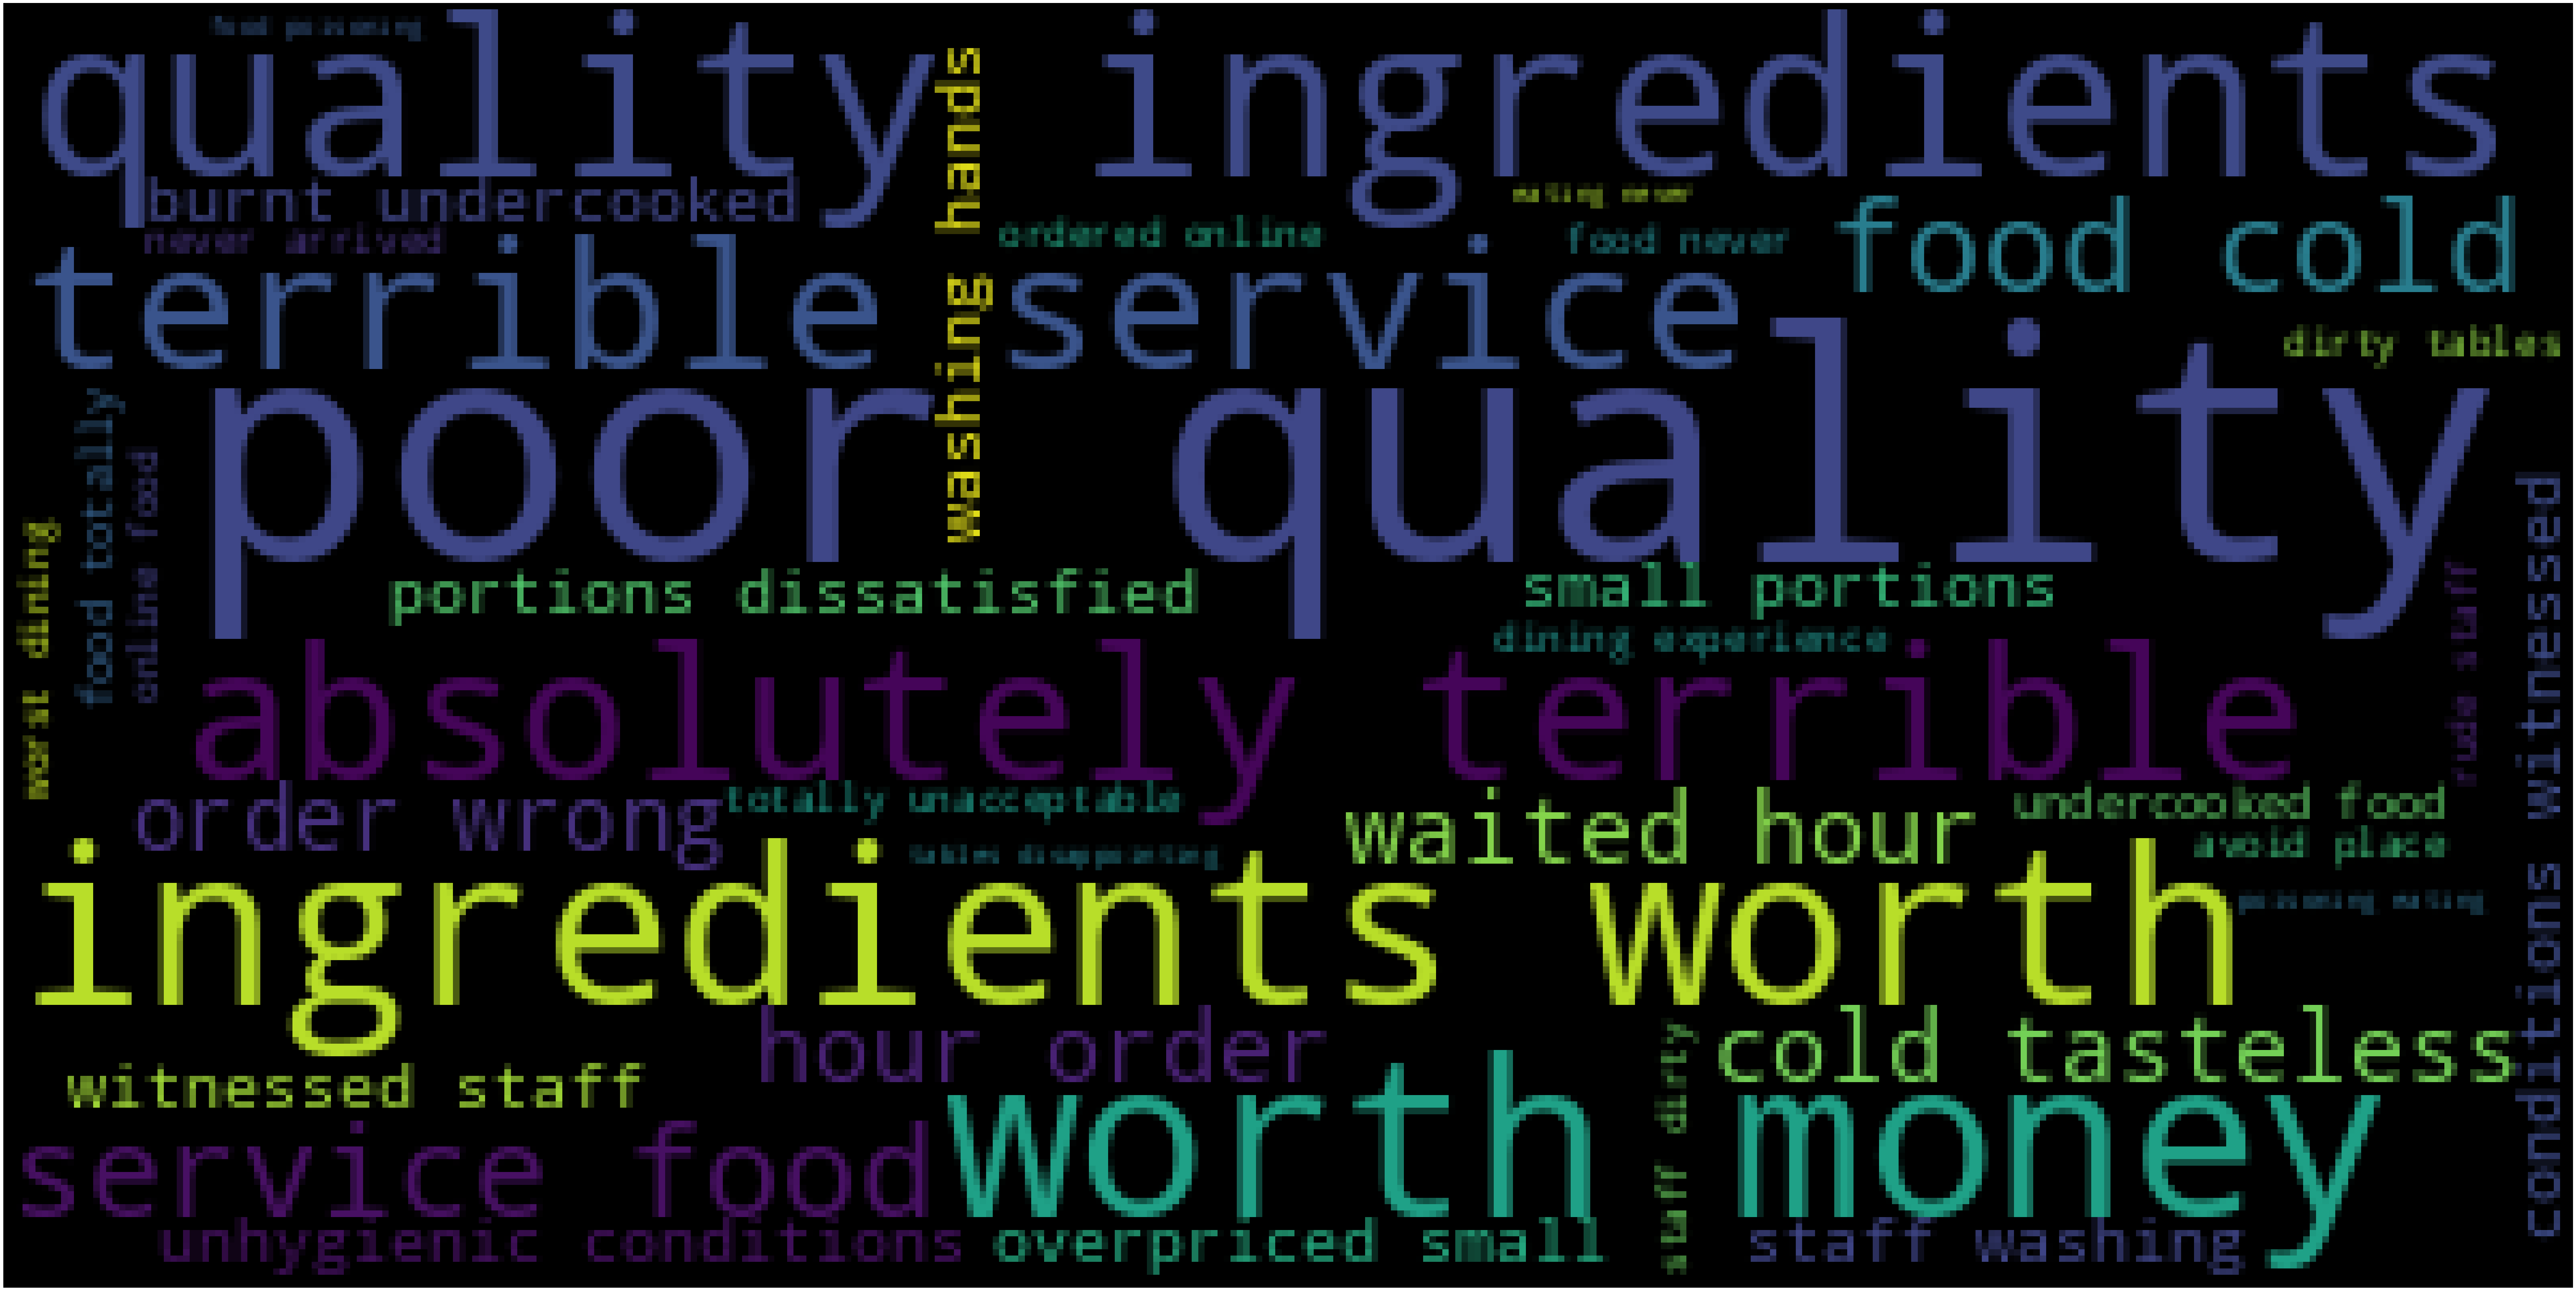

In [ ]:
bad_rff_google_df = rff_google_df[rff_google_df["Review Stars"] < 3]
word_cloud_display(bad_rff_google_df, 'Review Text')

That is very interesting for our Google review dataset. Food, staff, service, price, place and experience all seem to be listed within the bad category.

Seems like there are some great insights to be found. Let's try TrustPilot now.

In [ ]:
rff_trustpilot_df.head()

,Review Text,Review Stars,Location,DateTime
0,Delicious meals and very clean environment.,4,London Chelsea,2023-07-31 02:24:00.048415
1,Terrible service and cold food.,1,Manchester Salford,2023-07-31 02:24:00.048415
2,"Amazing experience, highly recommend.",4,London Canary Wharf,2023-07-31 02:24:00.048415
3,"It was alright, the service could be better.",3,Leeds City Centre,2023-07-31 02:24:00.048415
4,"Awful place, would not recommend.",1,London Canary Wharf,2023-07-31 02:24:00.048415


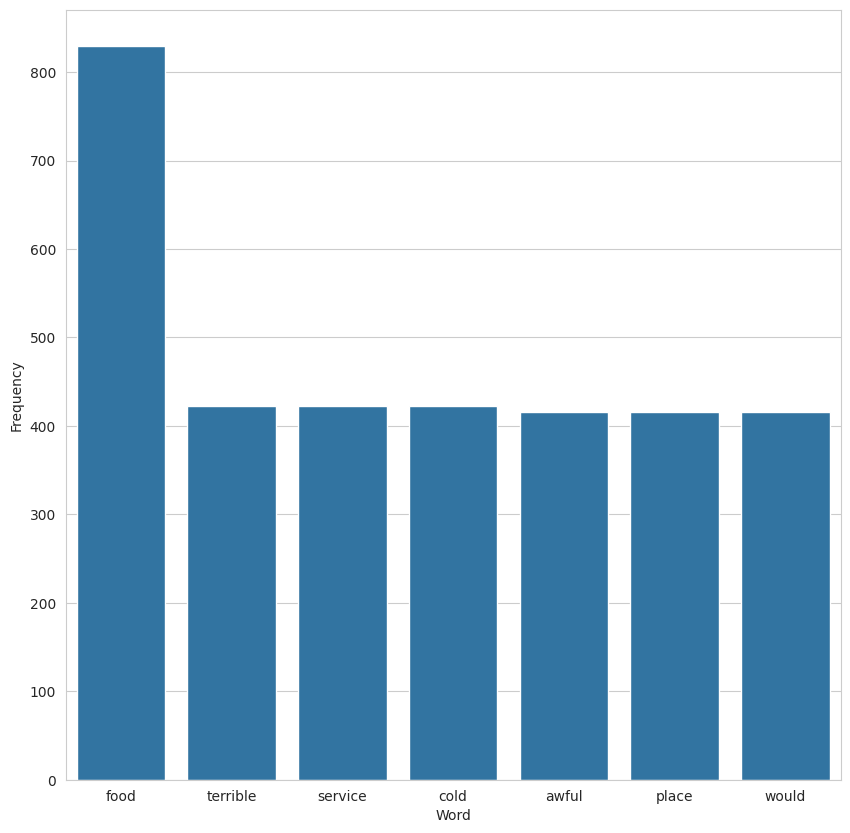

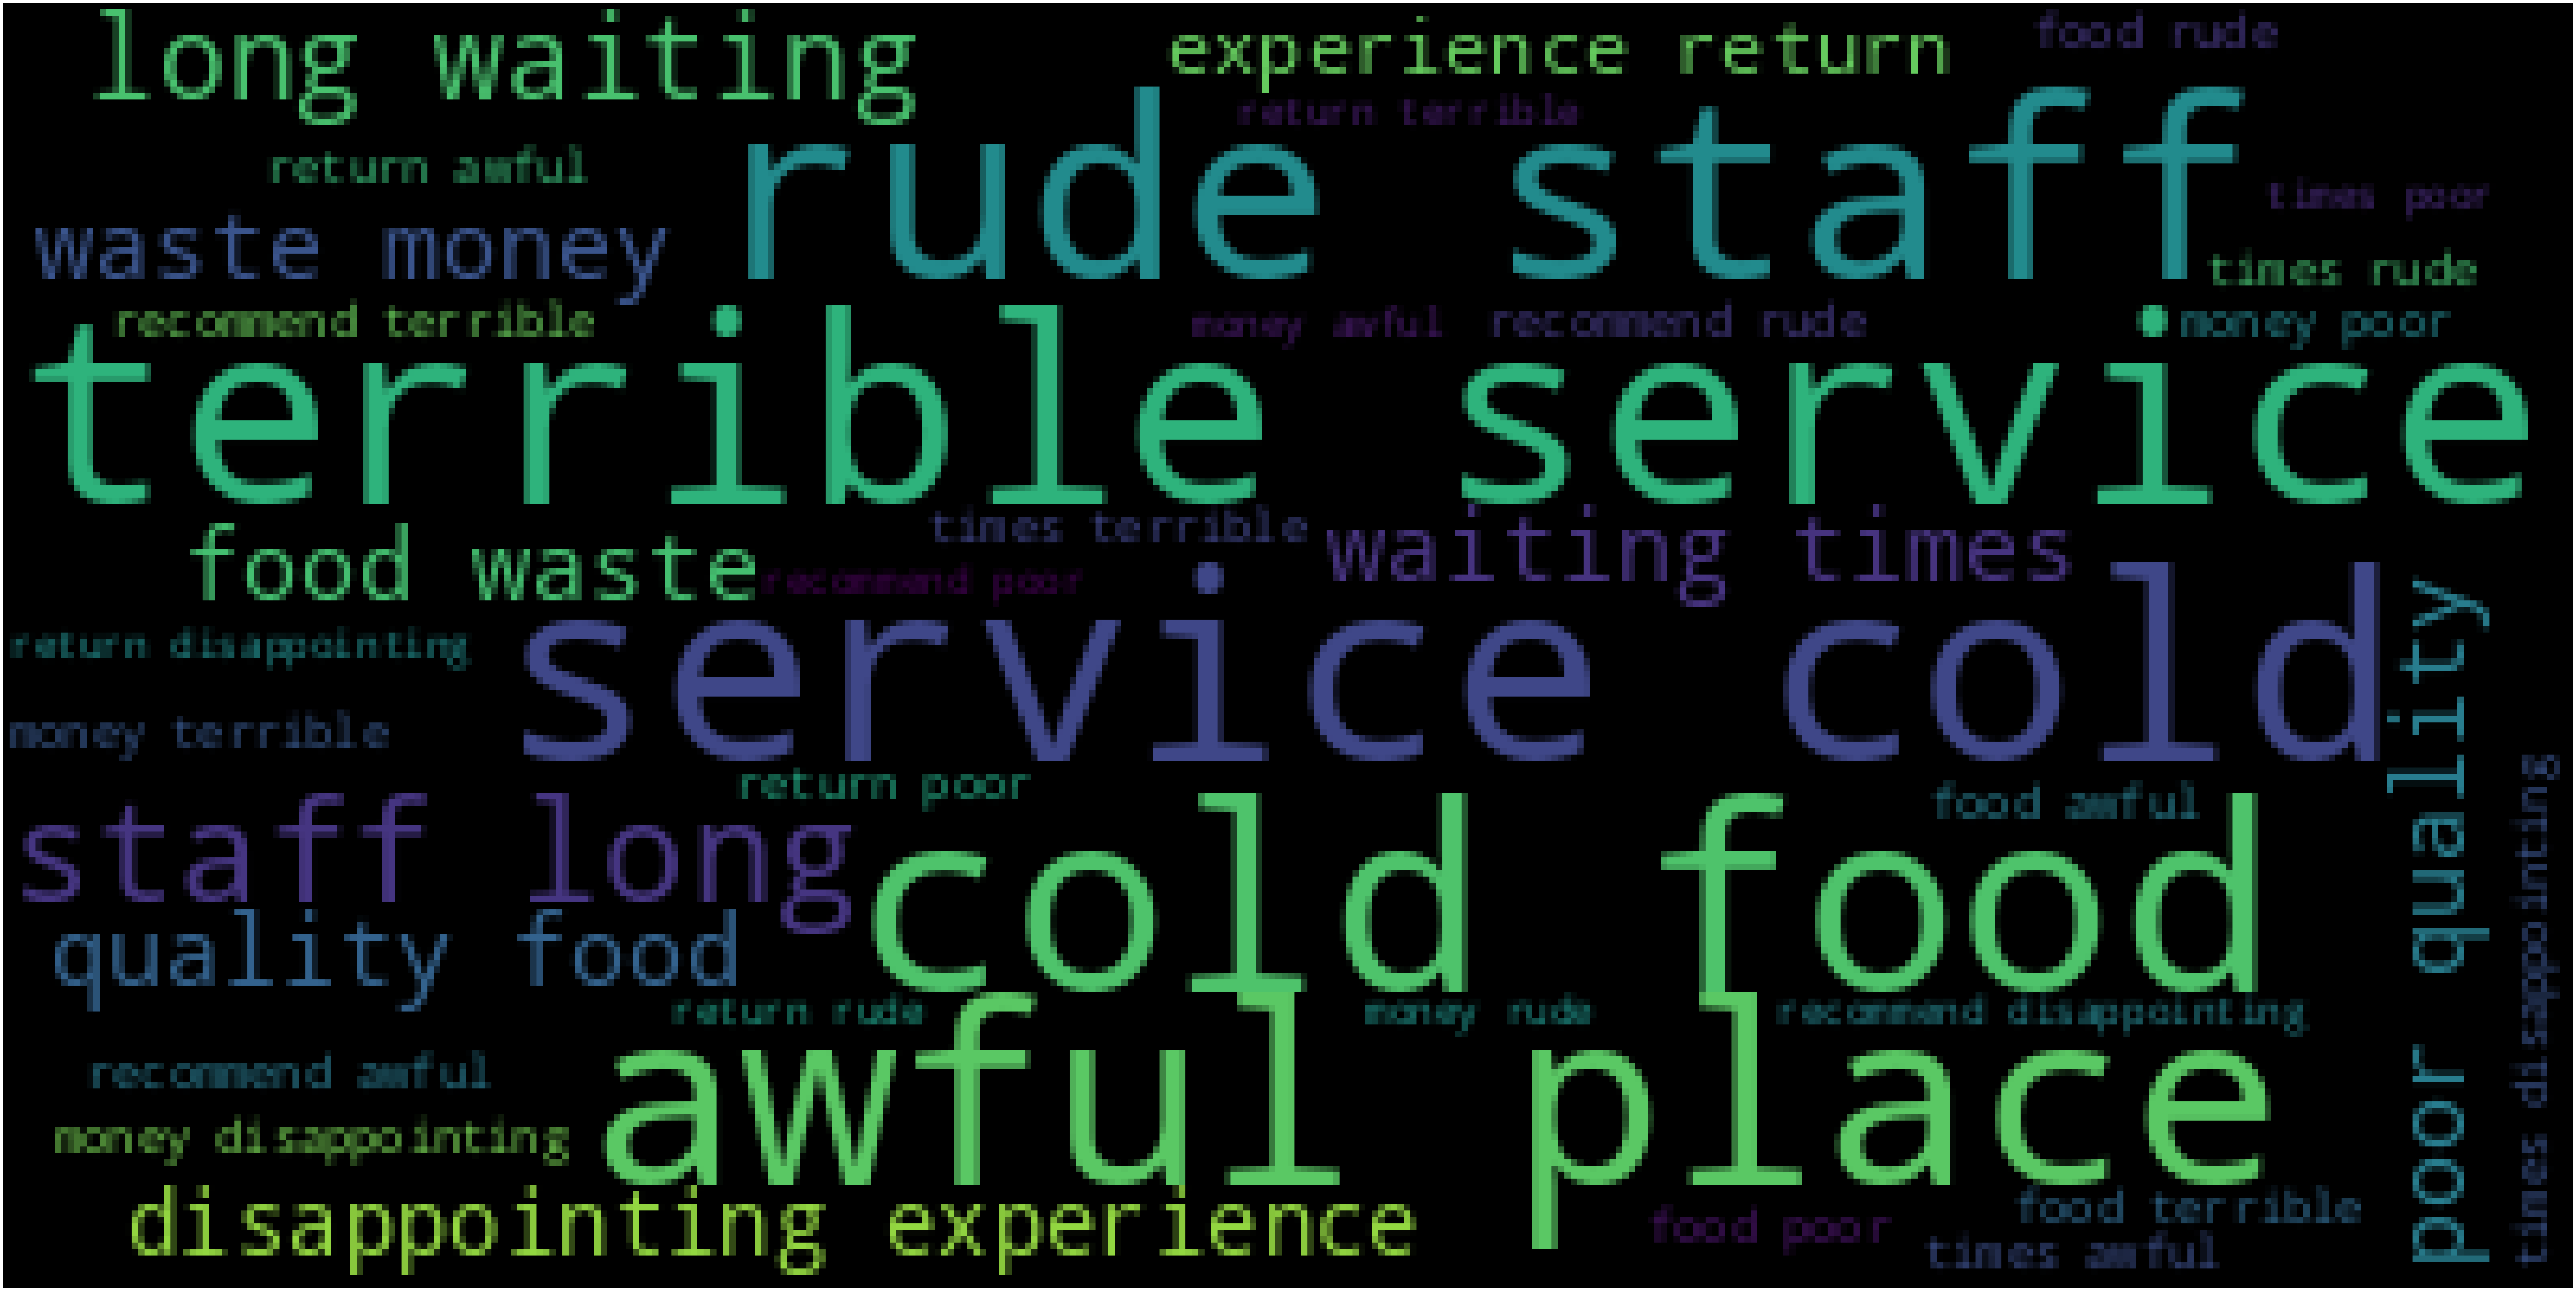

In [ ]:
bad_rff_trustpilot_df = rff_trustpilot_df[rff_trustpilot_df["Review Stars"] < 3]
word_cloud_display(bad_rff_trustpilot_df, 'Review Text')

Interesting, it looks like there are differences in datasets and the way people review. TrustPilot seems more concerned with the service where as Google reviews seem to be concerned with the quality.

This is interesting.

# Topic Modeling - BERT

You have used Gensim.

As you saw over the last two lectures, we can utilise BERT to solve many problems, including Topic Modeling.

We do this using BertTopic

In [ ]:
from transformers import pipeline

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


https://maartengr.github.io/BERTopic/index.html

Here, we will use a pre-trained model that has not been fine tuned to see what we get.

You will likely need to fine tune it as you have done in the exercises when it comes to the real-world example.

Here, we will get all reviews and put them into a list.

In [ ]:
len(bad_rff_google_df)

8353

In [ ]:
bad_rff_google_df_both_locations = bad_rff_google_df[bad_rff_google_df["Restaurant Place"].isin(intersection_of_locations)]
bad_rff_google_df_both_locations["Review Text"] = bad_rff_google_df_both_locations["Review Text"].astype(str)
bad_google_reviews_list = bad_rff_google_df_both_locations["Review Text"].to_list()

In [ ]:
len(bad_google_reviews_list)

8353

In [ ]:
len(bad_rff_trustpilot_df)

2058

In [ ]:
bad_rff_trustpilot_df_both_locations = bad_rff_trustpilot_df[bad_rff_trustpilot_df["Location"].isin(intersection_of_locations)]
bad_rff_trustpilot_df_both_locations["Review Text"] = bad_rff_trustpilot_df_both_locations["Review Text"].astype(str)
bad_trustpilot_reviews_list = bad_rff_trustpilot_df_both_locations["Review Text"].to_list()

In [ ]:
len(bad_trustpilot_reviews_list)

2058

In [ ]:
all_bad_reviews_list = bad_google_reviews_list + bad_trustpilot_reviews_list

Let's quickly check our list by looking at the first element.

In [ ]:
all_bad_reviews_list[0]

'Decent food, but the service was lacking.'

Let's clean our data by removing nulls and stopwords.

In [ ]:
all_bad_reviews_list_clean = []
for review in all_bad_reviews_list:
  #print(review)
  if review is not None and review != "nan":
    review = review.lower()
    review = re.sub('[^A-Za-z]+', ' ', review)

    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(review)

    for w in word_tokens:
      if w in stop_words:
        review = review.replace(" " + w + " ", " ")
    all_bad_reviews_list_clean.append(review)

Let's do a quick check.

In [ ]:
print(all_bad_reviews_list_clean[0])

decent food service lacking 


Ok, now, let's use BERTopic by passing in all of our cleaned bad reviews. This could take a minute or two.

In [ ]:
model = BERTopic(verbose=True)
model.fit(all_bad_reviews_list_clean)
topic, probabilities = model.transform(all_bad_reviews_list_clean)

2025-12-11 11:44:14,759 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/326 [00:00<?, ?it/s]

2025-12-11 11:44:26,152 - BERTopic - Embedding - Completed ✓
2025-12-11 11:44:26,155 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-11 11:45:26,785 - BERTopic - Dimensionality - Completed ✓
2025-12-11 11:45:26,787 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-11 11:45:27,223 - BERTopic - Cluster - Completed ✓
2025-12-11 11:45:27,230 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-11 11:45:27,288 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/326 [00:00<?, ?it/s]

2025-12-11 11:45:29,621 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-11 11:45:29,650 - BERTopic - Dimensionality - Completed ✓
2025-12-11 11:45:29,650 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-11 11:45:30,025 - BERTopic - Cluster - Completed ✓


Sometimes you will need to run this a couple of times to get it to make the most sense.

In [ ]:
model.get_topic_freq().head(10)

,Topic,Count
14,0,819
6,1,816
5,2,786
7,3,772
13,4,771
15,5,761
11,6,760
10,7,755
9,8,747
53,9,423


It looks like we have a sizeable number of outliers (topic -1) and should typically be ignored. Next, let's take a look at the most frequent topic that was generated, topic 0

In [ ]:
model.get_topic(0)

[('tasteless', np.float64(0.12063463882578841)),
 ('absolutely', np.float64(0.12063463882578841)),
 ('terrible', np.float64(0.08848539705545466)),
 ('cold', np.float64(0.08848539705545466)),
 ('service', np.float64(0.07769277477530499)),
 ('food', np.float64(0.031079276019543016)),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05)]

- TODO: These update on every run.

In [ ]:
model.get_topic(1)

[('order', np.float64(0.18142494589942346)),
 ('hour', np.float64(0.18142494589942346)),
 ('wrong', np.float64(0.18142494589942346)),
 ('waited', np.float64(0.18142494589942346)),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05)]

- TODO: These update on every run.

Let's have a look at all the clusters in an Intertopic Distance Map and see if we have any overlapping insights.

In [ ]:
model.visualize_topics()

- TODO: discuss more about clusters.

Some nice insights and, perhaps, low hanging fruit. There are some other tools for visualising the insights, like the below bar charts.

In [ ]:
model.visualize_barchart()

We can review a heatmap, but in sometimes this is quite difficult to follow.

In [ ]:
model.visualize_heatmap()

And finally some hierarchical clustering which shows a dendogram.

In [ ]:
hierarchical_topics = model.hierarchical_topics(all_bad_reviews_list_clean)
model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 56/56 [00:00<00:00, 373.69it/s]


From what we have seen so far, we could certainly take the clusters and start to understand what our actionable insights should cover.

However, there are some other things to consider here. Let's return to the part about locations.

In [ ]:
bad_rff_trustpilot_df_by_location = bad_rff_trustpilot_df.copy()
bad_trustpilot_df_by_location = bad_rff_trustpilot_df_by_location[["Location"]]
bad_rff_trustpilot_df_by_location = bad_rff_trustpilot_df_by_location.dropna()
bad_rff_trustpilot_df_by_location["Location"] = bad_rff_trustpilot_df_by_location["Location"].astype(str)
bad_rff_trustpilot_df_by_location = bad_rff_trustpilot_df_by_location.groupby(["Location"])["Location"].count().reset_index(name='total_count_tp')
bad_rff_trustpilot_df_by_location_sorted = bad_rff_trustpilot_df_by_location.sort_values(by=['total_count_tp'], ascending=False)

In [ ]:
bad_rff_trustpilot_df_by_location_sorted.head(20)

,Location,total_count_tp
16,London Canary Wharf,167
15,London Camden,158
17,London Chelsea,155
18,London Hackney,152
19,London Soho,127
20,Manchester Central,100
0,Birmingham City Centre,100
22,Manchester Salford,98
1,Birmingham Edgbaston,92
2,Birmingham Solihull,90


In [ ]:
bad_rff_google_df_by_location = bad_rff_google_df.copy()
bad_rff_google_df_by_location = bad_rff_google_df_by_location[["Restaurant Place"]]
bad_rff_google_df_by_location = bad_rff_google_df_by_location.dropna()
bad_rff_google_df_by_location["Restaurant Place"] = bad_rff_google_df_by_location["Restaurant Place"].astype(str)
bad_rff_google_df_by_location = bad_rff_google_df_by_location.groupby(["Restaurant Place"])["Restaurant Place"].count().reset_index(name='total_count_g')
bad_rff_google_df_by_location_sorted = bad_rff_google_df_by_location.sort_values(by=['total_count_g'], ascending=False)

In [ ]:
bad_rff_google_df_by_location_sorted.head(20)

,Restaurant Place,total_count_g
17,London Chelsea,642
18,London Hackney,592
15,London Camden,591
19,London Soho,585
16,London Canary Wharf,580
0,Birmingham City Centre,438
2,Birmingham Solihull,427
20,Manchester Central,418
22,Manchester Salford,416
1,Birmingham Edgbaston,412


In [ ]:
merged_location_bad_reviews_count_df = pd.merge(bad_rff_trustpilot_df_by_location_sorted, bad_rff_google_df_by_location_sorted, how='left', left_on='Location', right_on='Restaurant Place')
merged_location_bad_reviews_count_df = merged_location_bad_reviews_count_df.dropna()
merged_location_bad_reviews_count_df.drop('Restaurant Place', axis=1, inplace=True)
merged_location_bad_reviews_count_df['total_count'] = merged_location_bad_reviews_count_df['total_count_tp'] + merged_location_bad_reviews_count_df['total_count_g']
merged_location_bad_reviews_count_df_sorted = merged_location_bad_reviews_count_df.sort_values(by=['total_count'], ascending=False)
print(len(merged_location_bad_reviews_count_df_sorted))
merged_location_bad_reviews_count_df_sorted.head(20)

25


,Location,total_count_tp,total_count_g,total_count
2,London Chelsea,155,642,797
1,London Camden,158,591,749
0,London Canary Wharf,167,580,747
3,London Hackney,152,592,744
4,London Soho,127,585,712
6,Birmingham City Centre,100,438,538
5,Manchester Central,100,418,518
9,Birmingham Solihull,90,427,517
7,Manchester Salford,98,416,514
8,Birmingham Edgbaston,92,412,504


Let's do some plotting about where most of the bad reviews are.

In [ ]:
from geopy.geocoders import Nominatim
import plotly.express as px

In [ ]:
loc = Nominatim(user_agent="Geopy Library")

In [ ]:
getLoc = loc.geocode("London Stratford")
print(getLoc.address)
print("Lat", getLoc.latitude, "Long", getLoc.longitude)

Stratford, Meridian Square, Stratford, London Borough of Newham, Greater London, England, E15 1DA, United Kingdom
Lat 51.541289 Long -0.0035472


In [ ]:
lat = []
long = []
for index, row in merged_location_bad_reviews_count_df_sorted.iterrows():
  getLoc = loc.geocode(row["Location"])
  if getLoc is not None:
    lat.append(getLoc.latitude)
    long.append(getLoc.longitude)
  else:
    lat.append(None)
    long.append(None)
    print(row["Location"])

GeocoderUnavailable: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=London+Hackney&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))

In [ ]:
merged_location_bad_reviews_count_df_sorted['lat'] = lat
merged_location_bad_reviews_count_df_sorted['long'] = long

In [ ]:
merged_location_bad_reviews_count_df_sorted.head(30)

In [ ]:
merged_location_bad_reviews_count_df_sorted = merged_location_bad_reviews_count_df_sorted[merged_location_bad_reviews_count_df_sorted["lat"] > 0]
merged_location_bad_reviews_count_df_sorted = merged_location_bad_reviews_count_df_sorted[merged_location_bad_reviews_count_df_sorted["long"] > -20]

In [ ]:
px.scatter(merged_location_bad_reviews_count_df_sorted, x="long", y="lat", hover_data=["Location", "total_count"], width=1000, height=1000)

Now, let's do top 10 locations (remember there are only 25).

In [ ]:
merged_location_bad_reviews_count_df_sorted_10 = merged_location_bad_reviews_count_df_sorted.head(10)
px.scatter(merged_location_bad_reviews_count_df_sorted_10, x="long", y="lat", hover_data=["Location", "total_count"], width=1000, height=1000)

In this instance, it seems that the restaurant bad reviews are fairly evenly split across Birmingham, Manchester and London. Which makes sense due to population.

However, using this, you will see that there is an opportunity to understand particularly bad reviews if spatial context is taken into consideration.

For example, one might expect that major cities, like London, would have more problems than places with fewer restaurants and that those problems would differ slightly.

Remember to consider this with the PureGym example, it will help refine your actionable insights.

# Emotion Analysis

Let's start with a simple off-the-shelf BERT model trained to return emotion rather than sentiment.

In [ ]:
classifier = pipeline("text-classification", model='bhadresh-savani/bert-base-uncased-emotion', return_all_scores=True)

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
test_prompt = "I love to hate this product"

In [ ]:
emotion_labels = classifier(test_prompt, )

In [ ]:
emotion_labels_sorted = sorted(emotion_labels[0], key=lambda x: x["score"], reverse=True)

In [ ]:
print(emotion_labels_sorted)

[{'label': 'anger', 'score': 0.9926347136497498}, {'label': 'sadness', 'score': 0.005297101102769375}, {'label': 'fear', 'score': 0.000703458848875016}, {'label': 'joy', 'score': 0.0005697517772205174}, {'label': 'love', 'score': 0.0005655562272295356}, {'label': 'surprise', 'score': 0.00022941677889321}]


If we can label each review using emotion analysis, we could perhaps refine the real pain points that users would like resolved.

# Gensim (LDA)

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.5 MB/s eta 0:00:00


In [ ]:
from gensim import corpora
from gensim.models import LdaModel
from pprint import pprint

In [ ]:
# 1. Example documents
#documents = [
#    "machine learning is fascinating",
#    "deep learning and machine learning",
#    "artificial intelligence and data science",
#    "data science uses machine learning"
#]

documents = all_bad_reviews_list_clean.copy()

# 2. Tokenise
texts = [[word.lower() for word in doc.split()] for doc in documents]

# 3. Create dictionary (word → id)
dictionary = corpora.Dictionary(texts)

# 4. Convert documents to Bag-of-Words
corpus = [dictionary.doc2bow(text) for text in texts]

# 5. Train LDA topic model
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=2,
    passes=10
)

# 6. Print discovered topics
pprint(lda.print_topics())

[(0,
  '0.113*"food" + 0.083*"staff" + 0.068*"service" + 0.064*"terrible" + '
  '0.064*"cold" + 0.063*"rude" + 0.058*"disappointing" + 0.044*"times" + '
  '0.044*"waiting" + 0.044*"long"'),
 (1,
  '0.066*"poor" + 0.066*"quality" + 0.066*"money" + 0.064*"experience" + '
  '0.063*"place" + 0.058*"food" + 0.043*"waste" + 0.042*"return" + '
  '0.042*"very" + 0.041*"recommend"')]


**Conclusions**

So far, we have a pretty good understanding of the problem, but certainly if we are going to obtain some better insights we will need to consider the topics and try to understand how and where we can improve:

1. Pricing could be reviewed.
2. Staff training in customer service.
3. Quality assurance protocol to ensure food is always prepared to standard
4. Cleanliness by employing more cleaning staff

However ....

This is perhaps due to location, for example, in highly populated areas where the restaurants are busy, are there underlying factors. Should more staff be employed for these locations. Perhaps making bespoke layouts to meet the particular needs. For example, there are McDonalds Ice Cream vendors in hot countries.

# Agentic-ish

For this we will use Ollama and Phi-4 mini

In [ ]:
!curl -fsSL https://ollama.ai/install.sh | sh
!echo 'debconf debconf/frontend select Noninteractive' | sudo debconf-set-selections
!sudo apt-get update && sudo apt-get install -y cuda-drivers
import os
os.environ.update({'LD_LIBRARY_PATH': '/usr/lib64-nvidia'})

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://cli.github.com/packages stable/main 

In [ ]:
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [ ]:
!ollama pull phi4-mini

In [ ]:
!pip install ollama

In [ ]:
import ollama

In [ ]:
!ollama list

NAME                ID              SIZE      MODIFIED       
phi4-mini:latest    78fad5d182a7    2.5 GB    18 seconds ago    


We need to compute our stats from earlier as we will pass them to our "agents". Hence, this is like a tool, to compute the word frequency stats.

In [ ]:
def compute_word_stats(df, text_col, top_n=100):
    # join all reviews
    all_reviews = df[text_col].astype(str).str.lower().str.cat(sep=' ')
    all_text = re.sub('[^A-Za-z]+', ' ', all_reviews)

    # basic token filtering
    tokens = word_tokenize(all_text)
    filtered = [w for w in tokens if w not in stop_words]
    filtered = [w for w in filtered if len(w) > 2 and not w.isnumeric()]

    # frequency distribution
    word_dist = nltk.FreqDist(filtered)
    freq_df = pd.DataFrame(
        word_dist.most_common(top_n),
        columns=['Word', 'Frequency']
    )

    # some simple summary stats you can analyse/compare
    summary = {
        "total_tokens": len(tokens),
        "filtered_tokens": len(filtered),
        "unique_tokens": freq_df.shape[0],
        "top_word": freq_df.iloc[0]["Word"] if not freq_df.empty else None,
        "top_word_freq": int(freq_df.iloc[0]["Frequency"]) if not freq_df.empty else 0
    }

    return freq_df, summary, filtered   # filtered tokens are useful for WordCloud




This function prints out, like before.

In [ ]:
def plot_wordcloud_and_bars(freq_df, tokens):
    # bar plot of top words
    plt.figure(figsize=(10,4))
    sns.set_style("whitegrid")
    sns.barplot(
        x="Word",
        y="Frequency",
        data=freq_df.head(7)
    )
    plt.xticks(rotation=45)
    plt.title("Top words")

    # word cloud
    plt.figure(figsize=(8,8))
    wc = WordCloud(
        background_color='black',
        max_words=1000,
        max_font_size=50
    )
    wc.generate(' '.join(tokens))
    plt.imshow(wc)
    plt.axis('off')
    plt.title("Word cloud")
    plt.show()

Let's run it for all trustpilot reviews

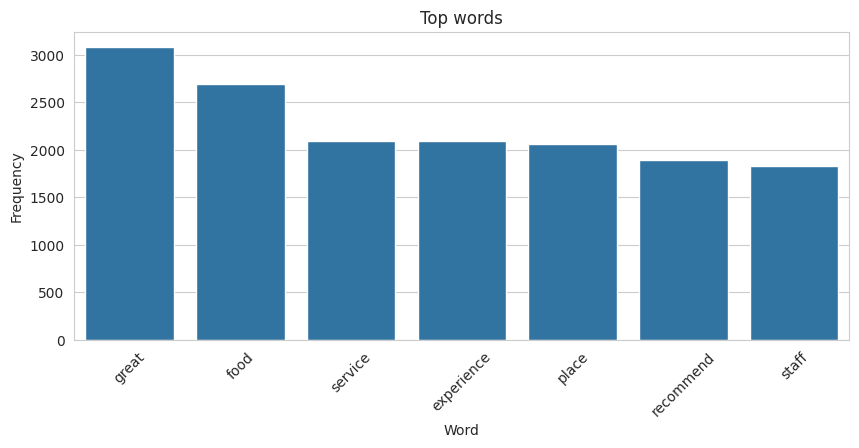

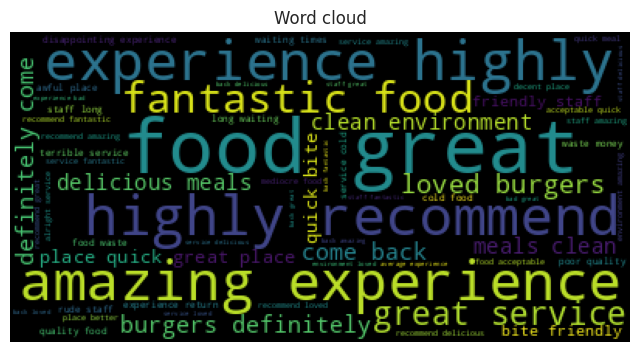

{'total_tokens': 63573, 'filtered_tokens': 46142, 'unique_tokens': 48, 'top_word': 'great', 'top_word_freq': 3086}
         Word  Frequency
0       great       3086
1        food       2695
2     service       2095
3  experience       2094
4       place       2064
5   recommend       1894
6       staff       1827
7       quick       1638
8     amazing       1478
9      highly       1478


In [ ]:
freq_df, summary, tokens = compute_word_stats(rff_trustpilot_df, "Review Text")
plot_wordcloud_and_bars(freq_df, tokens)
print(summary)
print(freq_df.head(10))

Good, now we will set-up our sources that range from google and tp all to google and tp negative and get put our stats into the results object.

In [ ]:
sources = {
    "trustpilot_all": rff_trustpilot_df,
    "google_all": rff_google_df,
    "trustpilot_negative": rff_trustpilot_df[rff_trustpilot_df["Review Stars"] <= 2],
    "google_negative": rff_google_df[rff_google_df["Review Stars"] <= 2]
}

results = {}

for name, df in sources.items():
    freq_df, summary, tokens = compute_word_stats(df, "Review Text")
    print(f"\n=== {name} ===")
    print(summary)
    print(freq_df.head(10))

    #plot_wordcloud_and_bars(freq_df, tokens)


    results[name] = {"freq_df": freq_df, "summary": summary}








=== trustpilot_all ===
{'total_tokens': 63573, 'filtered_tokens': 46142, 'unique_tokens': 48, 'top_word': 'great', 'top_word_freq': 3086}
         Word  Frequency
0       great       3086
1        food       2695
2     service       2095
3  experience       2094
4       place       2064
5   recommend       1894
6       staff       1827
7       quick       1638
8     amazing       1478
9      highly       1478

=== google_all ===
{'total_tokens': 145988, 'filtered_tokens': 100772, 'unique_tokens': 81, 'top_word': 'food', 'top_word_freq': 7025}
         Word  Frequency
0        food       7025
1       great       4371
2     service       3998
3       staff       3594
4       place       3505
5  experience       3475
6       quick       2364
7        bite       2067
8    friendly       2067
9   fantastic       2059

=== trustpilot_negative ===
{'total_tokens': 11509, 'filtered_tokens': 8645, 'unique_tokens': 20, 'top_word': 'food', 'top_word_freq': 829}
        Word  Frequency
0       fo

Next we need to do the same for BERTopic

In [ ]:
topic_info_df = model.get_topic_info()

# Drop outliers
topic_info_df = topic_info_df[topic_info_df["Topic"] != -1]

topic_summaries = {}

for _, row in topic_info_df.iterrows():
    topic_id = int(row["Topic"])
    words = model.get_topic(topic_id)  # list of (word, weight)

    if words:
        top_words = [w for w, _ in words[:5]]
        label = ", ".join(top_words)
    else:
        top_words = []
        label = "No keywords"

    topic_summaries[topic_id] = {
        "label": label,
        "top_words": top_words,
        "count": int(row["Count"])
    }




# Assume `topics` and `probabilities` are the outputs from BERTopic
# topics: list/array of topic ids per document
# probabilities: 1D or 2D array; here we assume 1D of max-topic probs

topics_arr = np.array(topic)
probs_arr = np.array(probabilities)

# Filter out -1 (outliers)
valid_mask = topics_arr != -1
valid_topics = topics_arr[valid_mask]
valid_probs = probs_arr[valid_mask]

topic_counts = Counter(int(t) for t in valid_topics)
top_topic_ids = [t for t, _ in topic_counts.most_common(5)]

top_topics = []
for t in top_topic_ids:
    meta = topic_summaries.get(t, {})
    top_topics.append({
        "topic_id": int(t),
        "name": meta.get("name"),
        "count": int(topic_counts[t]),
    })

results["bad_google_and_tp_berttopic"] = {
    "n_docs": int(len(topics_arr)),
    "n_assigned": int(valid_mask.sum()),
    "topic_counts": {int(k): int(v) for k, v in topic_counts.items()},
    "top_topics": top_topics,
    "probability_stats": {
        "mean": float(valid_probs.mean()) if len(valid_probs) else None,
        "min":  float(valid_probs.min())  if len(valid_probs) else None,
        "max":  float(valid_probs.max())  if len(valid_probs) else None,
    },
    "topic_summaries": topic_summaries,  # already compact
}

In [ ]:
print("results", results)

results {'trustpilot_all': {'freq_df':              Word  Frequency
0           great       3086
1            food       2695
2         service       2095
3      experience       2094
4           place       2064
5       recommend       1894
6           staff       1827
7           quick       1638
8         amazing       1478
9          highly       1478
10      fantastic       1456
11          loved       1449
12        burgers       1449
13     definitely       1449
14           come       1449
15           back       1449
16      delicious       1436
17          meals       1436
18          clean       1436
19    environment       1436
20           bite       1417
21       friendly       1417
22         better        447
23       terrible        423
24           cold        423
25          awful        416
26          would        416
27           rude        410
28           long        410
29        waiting        410
30          times        410
31           poor        406
32  

Same for LDA. This is all reviews like with BERTopic.

In [ ]:
# Get topics in a structured way (no formatted string)
lda_topics_raw = lda.show_topics(num_topics=-1, num_words=10, formatted=False)
# => [(topic_id, [(word, weight), ...]), ...]

lda_topics_structured = []
for topic_id, word_weights in lda_topics_raw:
    lda_topics_structured.append({
        "topic_id": int(topic_id),
        "top_words": [
            {"word": w, "weight": float(wt)} for w, wt in word_weights
        ]
    })

results["bad_google_and_tp_lda"] = {
    "model": "lda",
    "n_topics": lda.num_topics,
    "topics": lda_topics_structured
}

Standard function for calling Phi using post requests (you can use Ollama directly).

In [ ]:
def call_phi(prompt):
    r = requests.post(
        "http://localhost:11434/api/generate",
        json={"model": "phi4", "prompt": prompt, "stream": False}
    )
    return r.json()["response"]

Here is the function using Ollama.

In [ ]:
def run_llm_generate(prompt: str,
                     model: str = "phi4-mini",
                     temperature: float = 0.2) -> str:
    """
    Use ollama.generate instead of chat; returns plain text.
    """
    response = ollama.generate(
        model=model,
        prompt=prompt,
        options={"temperature": temperature},
    )
    # response["response"] usually contains the full text when not streaming
    return response["response"].strip()

Create a compression agent for the word frequency stats i.e. create a small report.

In [ ]:
def compression_agent(name, freq_df, summary):
    # keep only top words to avoid huge prompts
    top_words = freq_df.head(30).to_dict(orient="records")
    payload = {
        "source": name,
        "summary": summary,
        "top_words": top_words
    }
    prompt = f"""
You are a data cleaning and insights assistant.

Here are word-frequency stats for customer reviews of Russells Famous Foods:
{json.dumps(payload, indent=2)}

1. Suggest any data-cleaning/normalisation rules (typos, synonyms, variants).
2. Briefly explain what these top words tell us about customer experience.
3. Highlight any obviously negative or risk-related terms.
Respond in bullet points.
"""
    #return call_phi(prompt)
    return run_llm_generate(prompt)

BERTopic reasoning agent for writing a small report on the data:

In [ ]:
def bertopic_reasoning_agent(source_name, topic_summaries, topic_info):
    """
    topic_info is the full dict containing:
    - n_docs
    - n_assigned
    - topic_counts
    - top_topics
    - probability_stats
    """

    payload = {
        "source": source_name,
        "n_docs": topic_info.get("n_docs"),
        "n_assigned": topic_info.get("n_assigned"),
        "topic_counts": topic_info.get("topic_counts"),
        "top_topics": topic_info.get("top_topics"),
        "probability_stats": topic_info.get("probability_stats"),
        "topic_summaries": topic_summaries
    }

    prompt = f"""
You are a customer experience risk analyst.

Below are BERTopic-generated complaint clusters for Russells Famous Foods.

{json.dumps(payload, indent=2)}

Tasks:
1. Assign a short, plain-English name to each major topic.
2. Identify operational failures.
3. Highlight any food safety risks.
4. Identify potential legal or reputational escalation.
"""

    return run_llm_generate(prompt)

Same for LDA

In [ ]:
def lda_reasoning_agent(source_name, lda_result):
    """
    lda_result is results["bad_google_and_tp_lda"], e.g.:
      {
        "model": "lda",
        "n_topics": 2,
        "topics": [
          {"topic_id": 0, "top_words": [...]},
          {"topic_id": 1, "top_words": [...]}
        ]
      }
    """
    payload = {
        "source": source_name,
        "model": lda_result.get("model"),
        "n_topics": lda_result.get("n_topics"),
        "topics": lda_result.get("topics")
    }

    prompt = f"""
You are a customer experience risk analyst.

Below are LDA-generated complaint topics for Russells Famous Foods.

{json.dumps(payload, indent=2)}

Tasks:
1. Give each topic a short, plain-English label (e.g. "Rude staff and poor service").
2. Describe in 2–3 bullet points what each topic is mainly about.
3. For each topic, identify:
   - Operational failures (process, staffing, training, etc.).
   - Any food safety risks you can infer.
   - Any potential legal or reputational escalation.
4. Briefly prioritise which topic(s) should be addressed first and why.
"""

    return run_llm_generate(prompt)






Create an agent to review all reports and compress them together with some level of critique using the "business problem".

In [ ]:
def overall_methodology_critic_agent(overall_analysis_outputs):
    """
    overall_analysis_outputs: list of strings
    Each entry is one completed LLM output (e.g. BERTopic analysis, LDA analysis, word-frequency analysis)
    """

    payload = {
        "n_reports": len(overall_analysis_outputs),
        "analyses": overall_analysis_outputs
    }

    prompt = f"""
You are a senior data science auditor and AI risk consultant.

You have been given multiple independent analytical outputs about customer complaints at
Russells Famous Foods. These outputs were generated using different NLP techniques
(e.g. word frequency analysis, BERTopic, LDA, and LLM summarisation).

Here is the full combined analytical evidence:

{json.dumps(payload, indent=2)}

Your job is to produce a **critical evaluation report** with the following structure:

-----------------------------------
1. TECHNICAL METHODOLOGY REVIEW
-----------------------------------
- Evaluate the suitability of:
  - Word frequency analysis
  - BERTopic
  - LDA
- Explain what *each method is good at* and what it *cannot reliably detect*.
- Identify risks of over-interpreting any single method.

-----------------------------------
2. DATA QUALITY & COVERAGE
-----------------------------------
- Assess:
  - Review platform bias (Google vs Trustpilot)
  - Negative-only filtering bias
  - Temporal drift risk
- Identify what *important data is missing* that would improve reliability.

-----------------------------------
3. CONSISTENCY & SIGNAL STRENGTH
-----------------------------------
- Identify which problem themes appear:
  - Consistently across multiple methods
  - Only in one method
- Highlight any contradictions between methods.
- Assess confidence level of:
  - Staff behaviour failures
  - Food quality risks
  - Hygiene risks

-----------------------------------
4. BUSINESS & LEGAL RISK RELIABILITY
-----------------------------------
- Rate the **reliability (Low / Medium / High)** of:
  - Operational failure evidence
  - Food safety risk evidence
  - Legal/reputational escalation risk
- Clearly explain *why* each reliability score is justified.

-----------------------------------
5. DECISION-MAKING WARNINGS
-----------------------------------
- What would be **dangerous or irresponsible** for management to assume based on this data?
- What actions **can** be justified with high confidence?
- What actions **require further verification or audits before acting?**

-----------------------------------
6. FINAL EXECUTIVE VERDICT
-----------------------------------
Provide a concise board-level verdict addressing:
- Whether this evidence is strong enough to justify:
  - A hygiene audit
  - Staff retraining
  - Supplier review
  - Legal review
- Overall confidence level in the analytical conclusions (0–100%).

IMPORTANT:
- Be critical, not sales-driven.
- Explicitly identify uncertainty.
- Do NOT soften weaknesses.
- Treat this as an expert witness report.
"""

    return run_llm_generate(prompt)

Lastly, let's loop through the data and create a final report using our "agents".

In [ ]:
overall_analysis = []

for name, info in results.items():
    #print("name", name)
    #print("info", info)
    if "freq_df" in info and "summary" in info:
      freq_df = info["freq_df"]
      summary = info["summary"]
      analysis = compression_agent(name, freq_df, summary)
      #print(f"\n### LLM analysis for {name} ###\n")
      title = f"\n### LLM analysis for {name} ###\n"
      #print(analysis)
      final_analysis = title + ' ' + analysis
      overall_analysis.append(final_analysis)

    if name == "bad_google_and_tp_berttopic":
      analysis = bertopic_reasoning_agent(
          name,
          info["topic_summaries"],
          info
      )
      #print(f"\n### LLM analysis for {name} ###\n")
      title = f"\n### LLM analysis for {name} ###\n"
      #print(analysis)
      final_analysis = title + ' ' + analysis
      overall_analysis.append(final_analysis)

    if name == "bad_google_and_tp_lda":
      title = f"\n### LLM analysis for {name} ###\n"

      lda_analysis = lda_reasoning_agent(
        "bad_google_and_tp_lda",
        results["bad_google_and_tp_lda"]
      )
      final_analysis = title + ' ' + lda_analysis
      overall_analysis.append(final_analysis)
      #print(lda_analysis)


final_critical_report = overall_methodology_critic_agent(overall_analysis)

print(final_critical_report)

**Critical Evaluation Report on Customer Complaints at Russells Famous Foods**

---

### 1. TECHNICAL METHODOLOGY REVIEW

#### Word Frequency Analysis
*Good At:*
- Identifies the most frequently mentioned words, providing a quick snapshot of common themes and sentiments.

*Cannot Reliably Detect:*
- Contextual meaning is lost; frequent mentions do not always indicate sentiment (e.g., "food" could mean good or bad).
  
Risks:
- Over-reliance on word frequency can lead to misinterpretation without context, missing nuanced complaints about specific issues like staff behavior.

---

#### BERTopic
*Good At:*
- Identifies coherent topics within the data by grouping similar words and phrases.
  
*Cannot Reliably Detect:*
- May miss subtle nuances or fail in cases where themes are not strongly represented across all documents (e.g., rare but significant complaints).

Risks:
- Over-interpreting BERTopic results without cross-validation can lead to overlooking less frequent yet critical issues.
